<a href="https://colab.research.google.com/github/Rafaaala/Desafio_Final_WKS_26.1/blob/main/BancoBox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

df = pd.read_csv('/content/banco_box_sintetico.csv')
df

,idade,renda_mensal,tempo_emprego,dividas_total,limite_cartao,historico_credito,num_cartoes_credito,num_emprestimos,atraso_pagamento,possui_imovel,possui_veiculo,cargo_atual,risco_credito
0,50,4145.83,1.4,5798,13957.29,1,1,1,0,Não,Não,Analista de TI,Médio
1,40,14080.13,0.9,39607,57549.72,1,0,2,0,Não,Não,Enfermeiro,Alto
2,59,7550.31,21.0,7865,20694.49,3,4,0,0,Não,Sim,Advogado,Médio
3,27,2390.01,5.6,1340,10593.18,17,5,3,0,Sim,Não,Analista de TI,Baixo
4,39,17135.27,20.3,45245,77949.94,1,3,2,0,Sim,Não,Contador,Alto
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,70,17133.71,10.4,36559,53726.07,7,3,0,0,Não,Não,Professor,Alto
996,82,8224.03,14.3,7642,18414.90,12,3,0,0,Sim,Não,Médico,Baixo
997,88,3286.20,19.1,1472,16055.81,12,0,1,0,Sim,Sim,Professor,Baixo
998,86,14855.40,26.6,42765,28284.90,6,3,0,0,Sim,Sim,Contador,Alto


In [13]:
df['renda_mensal'] = pd.to_numeric(df['renda_mensal'])
df['dividas_total'] = pd.to_numeric(df['dividas_total'])

df['relacao_divida'] = df['dividas_total'] / df['renda_mensal']
df.to_csv('dados_tratados.csv', index=False)

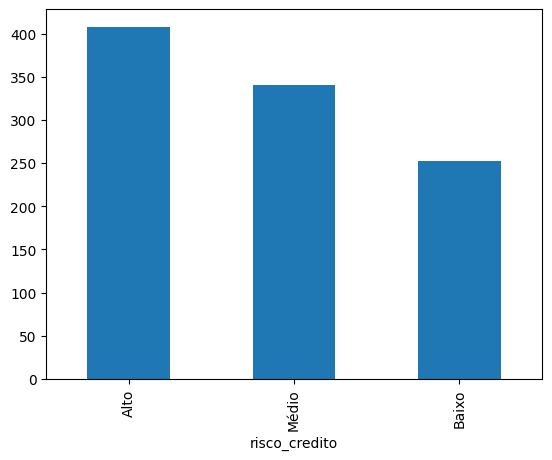

In [14]:
import matplotlib.pyplot as plt

df['risco_credito'].value_counts().plot(kind='bar')
plt.show()

In [15]:
import numpy as np

media = np.mean(df['historico_credito'])
print(media)

9.95


Acurácia: 0.82


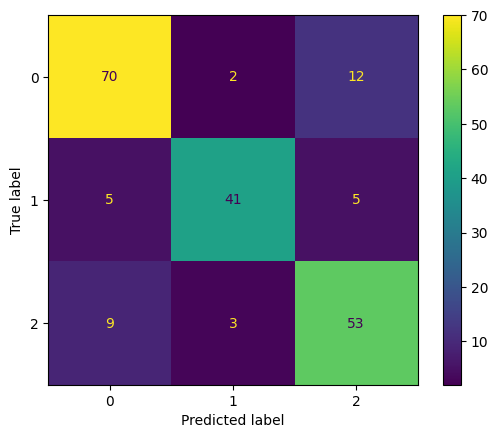

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X = df[['renda_mensal', 'dividas_total', 'relacao_divida']]
y = df['risco_credito']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

modelo = DecisionTreeClassifier()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("Acurácia:", modelo.score(X_test, y_test))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()